LATIHAN 1: KNN UNTUK DIGIT RECOGNITION
Dataset Shape: (1797, 64)
Number of Classes: 10


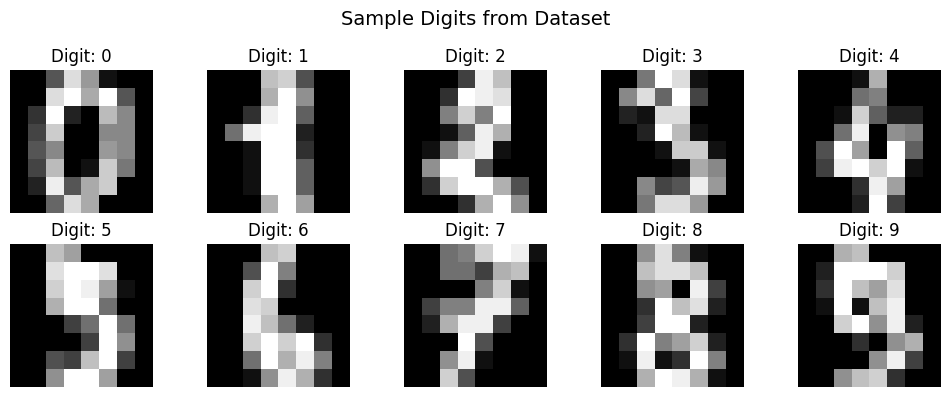

k=1: CV Accuracy=0.9865, Test Accuracy=0.9870
k=3: CV Accuracy=0.9849, Test Accuracy=0.9870
k=5: CV Accuracy=0.9825, Test Accuracy=0.9870
k=7: CV Accuracy=0.9809, Test Accuracy=0.9833
k=9: CV Accuracy=0.9769, Test Accuracy=0.9778
k=11: CV Accuracy=0.9729, Test Accuracy=0.9796


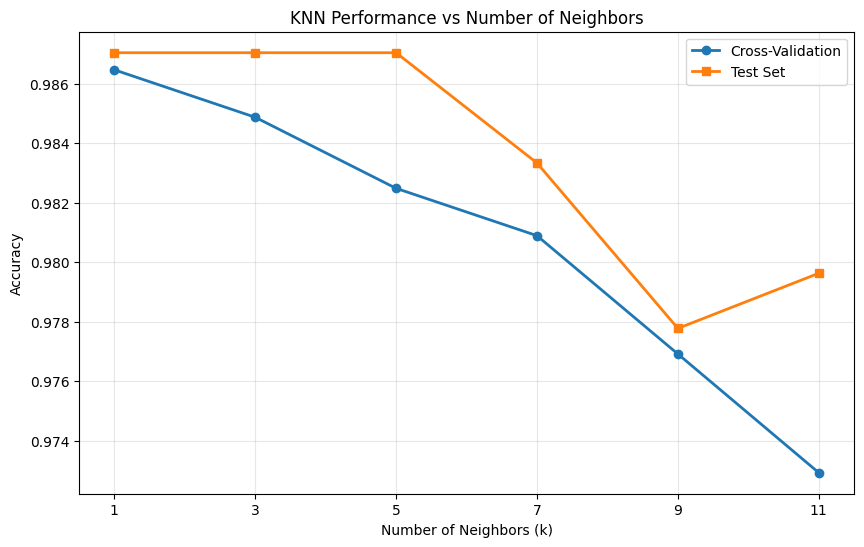


Best k value: 1


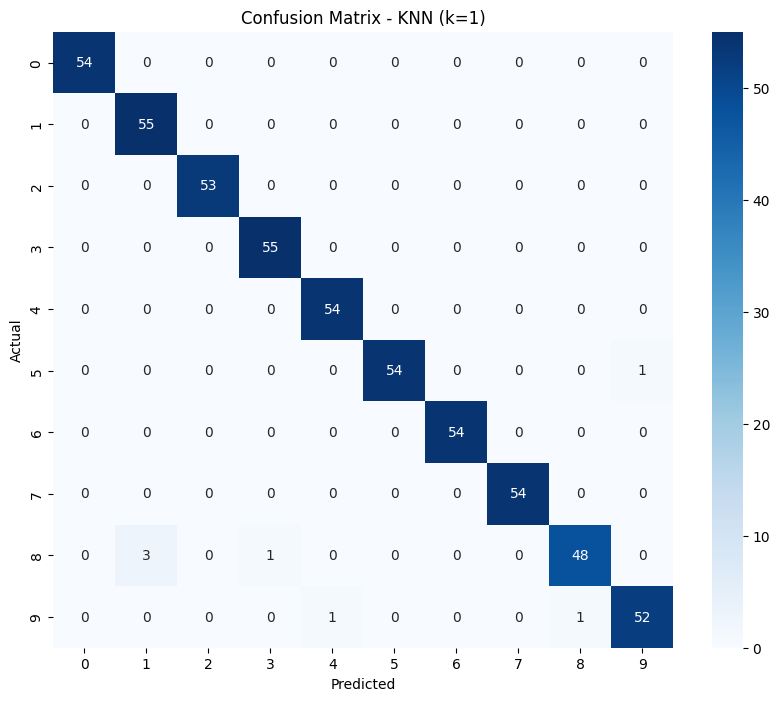


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        54
           1       0.95      1.00      0.97        55
           2       1.00      1.00      1.00        53
           3       0.98      1.00      0.99        55
           4       0.98      1.00      0.99        54
           5       1.00      0.98      0.99        55
           6       1.00      1.00      1.00        54
           7       1.00      1.00      1.00        54
           8       0.98      0.92      0.95        52
           9       0.98      0.96      0.97        54

    accuracy                           0.99       540
   macro avg       0.99      0.99      0.99       540
weighted avg       0.99      0.99      0.99       540


Number of misclassifications: 7/540 (1.30%)

Sample Misclassifications:


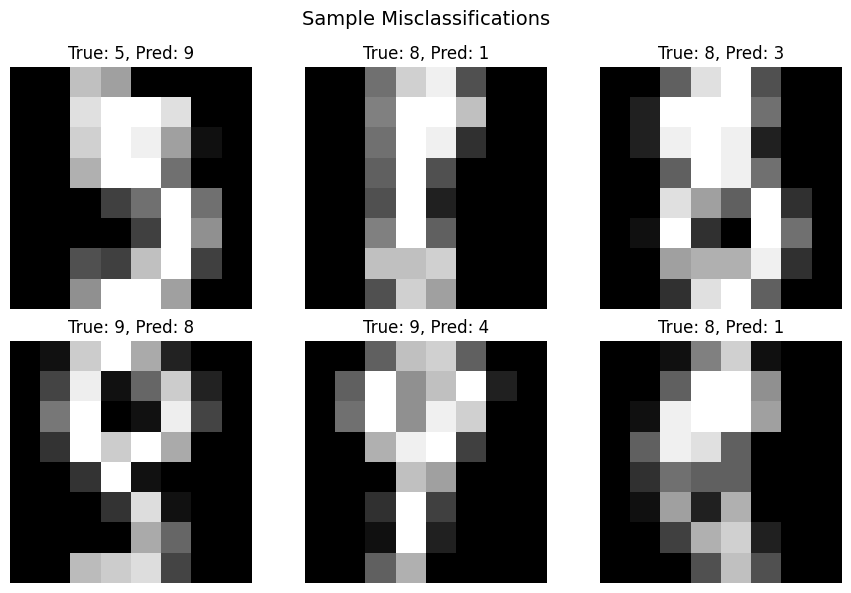

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Latihan 1: KNN untuk Digit Recognition
def praktikum_knn_digit():
    print("LATIHAN 1: KNN UNTUK DIGIT RECOGNITION")
    print("=" * 50)
    
    # Load dataset digit MNIST
    digits = load_digits()
    X = digits.data
    y = digits.target
    
    print(f"Dataset Shape: {X.shape}")
    print(f"Number of Classes: {len(np.unique(y))}")
    
    # Visualize sample digits
    fig, axes = plt.subplots(2, 5, figsize=(10, 4))
    for i, ax in enumerate(axes.flat):
        ax.imshow(X[i].reshape(8, 8), cmap='gray')
        ax.set_title(f"Digit: {y[i]}")
        ax.axis('off')
    plt.suptitle("Sample Digits from Dataset", fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    
    # Experiment with different k values
    k_values = [1, 3, 5, 7, 9, 11]
    cv_scores = []
    test_scores = []
    
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k)
        
        # Cross-validation score
        cv_score = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
        cv_scores.append(cv_score.mean())
        
        # Test score
        knn.fit(X_train, y_train)
        test_score = knn.score(X_test, y_test)
        test_scores.append(test_score)
        
        print(f"k={k}: CV Accuracy={cv_score.mean():.4f}, Test Accuracy={test_score:.4f}")
    
    # Plot results
    plt.figure(figsize=(10, 6))
    plt.plot(k_values, cv_scores, 'o-', label='Cross-Validation', linewidth=2)
    plt.plot(k_values, test_scores, 's-', label='Test Set', linewidth=2)
    plt.xlabel('Number of Neighbors (k)')
    plt.ylabel('Accuracy')
    plt.title('KNN Performance vs Number of Neighbors')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(k_values)
    plt.show()
    
    # Choose best k and evaluate
    best_k = k_values[np.argmax(cv_scores)]
    print(f"\nBest k value: {best_k}")
    
    knn_best = KNeighborsClassifier(n_neighbors=best_k)
    knn_best.fit(X_train, y_train)
    y_pred = knn_best.predict(X_test)
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=range(10), yticklabels=range(10))
    plt.title(f'Confusion Matrix - KNN (k={best_k})')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # Error analysis
    errors = np.where(y_pred != y_test)[0]
    print(f"\nNumber of misclassifications: {len(errors)}/{len(y_test)} ({len(errors)/len(y_test)*100:.2f}%)")
    
    if len(errors) > 0:
        print("\nSample Misclassifications:")
        fig, axes = plt.subplots(2, 3, figsize=(9, 6))
        for i, idx in enumerate(errors[:6]):
            ax = axes[i//3, i%3]
            ax.imshow(X_test[idx].reshape(8, 8), cmap='gray')
            ax.set_title(f"True: {y_test[idx]}, Pred: {y_pred[idx]}")
            ax.axis('off')
        plt.suptitle("Sample Misclassifications", fontsize=14)
        plt.tight_layout()
        plt.show()
    
    return knn_best, X_test, y_test, y_pred

# Jalankan latihan 1
knn_model, X_test, y_test, y_pred = praktikum_knn_digit()


LATIHAN 2: SVM DENGAN BERBAGAI KERNEL
Dataset Shape: (300, 20)
Class Distribution: [100 100 100]


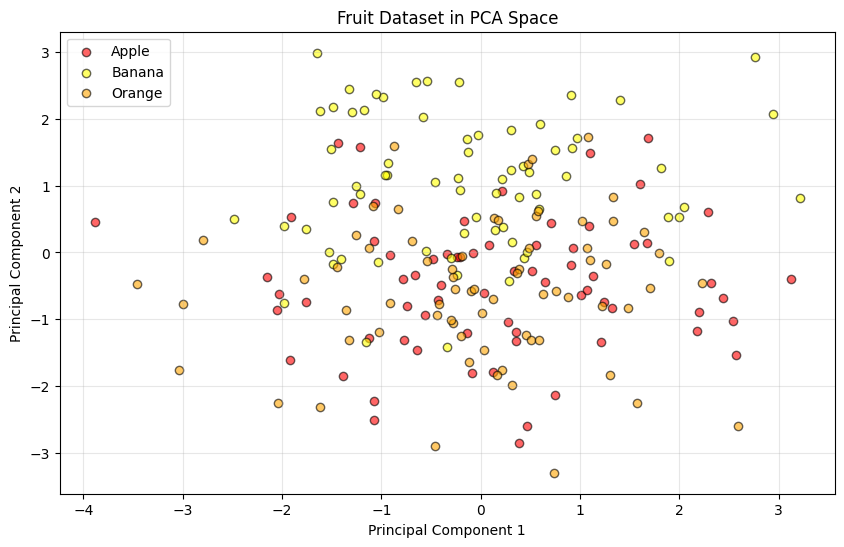

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 20)

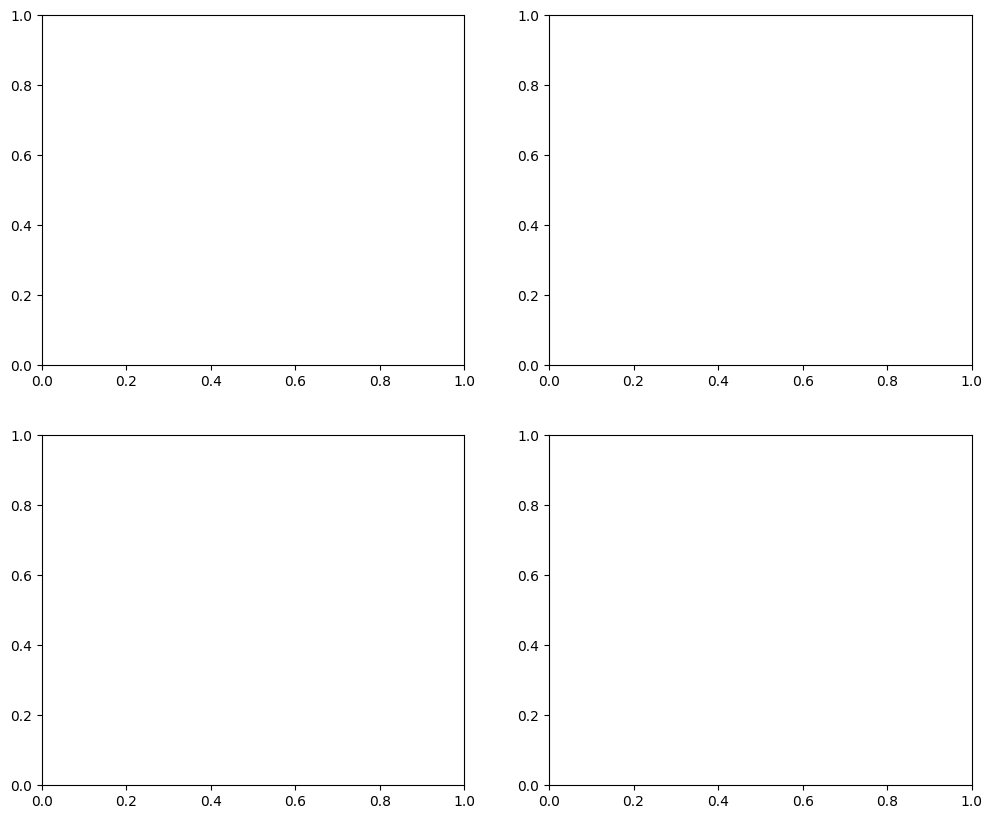

In [6]:
from sklearn import svm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
import warnings
warnings.filterwarnings('ignore')

# Latihan 2: SVM dengan berbagai kernel
def praktikum_svm_fruits():
    print("\nLATIHAN 2: SVM DENGAN BERBAGAI KERNEL")
    print("=" * 50)
    
    # Create synthetic fruit dataset
    def create_fruit_dataset(n_samples=300):
        np.random.seed(42)
        n_features = 20
        
        # Three fruit classes with different characteristics
        # Class 0: Apples (spherical, red)
        apples = np.random.randn(n_samples, n_features)
        apples[:, 0] += 2  # Red color feature
        apples[:, 1] += 1  # Roundness feature
        apples_labels = np.zeros(n_samples)
        
        # Class 1: Bananas (elongated, yellow)
        bananas = np.random.randn(n_samples, n_features)
        bananas[:, 0] += 1  # Yellow color feature
        bananas[:, 1] += 3  # Elongation feature
        bananas_labels = np.ones(n_samples)
        
        # Class 2: Oranges (spherical, orange)
        oranges = np.random.randn(n_samples, n_features)
        oranges[:, 0] += 1.5  # Orange color feature
        oranges[:, 1] += 1   # Roundness feature
        oranges[:, 2] += 2   # Texture feature
        oranges_labels = np.ones(n_samples) * 2
        
        X = np.vstack([apples, bananas, oranges])
        y = np.hstack([apples_labels, bananas_labels, oranges_labels])
        
        return X, y
    
    X, y = create_fruit_dataset(100)
    fruit_names = ['Apple', 'Banana', 'Orange']
    
    print(f"Dataset Shape: {X.shape}")
    print(f"Class Distribution: {np.bincount(y.astype(int))}")
    
    # Split and preprocess data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Reduce dimensionality for visualization
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_train_scaled)
    
    # Visualize data in PCA space
    plt.figure(figsize=(10, 6))
    colors = ['red', 'yellow', 'orange']
    for i, color in enumerate(colors):
        plt.scatter(X_pca[y_train == i, 0], X_pca[y_train == i, 1], 
                   c=color, label=fruit_names[i], alpha=0.6, edgecolors='black')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.title('Fruit Dataset in PCA Space')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Experiment with different SVM kernels
    kernels = ['linear', 'poly', 'rbf', 'sigmoid']
    results = {}
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.ravel()
    
    for idx, kernel in enumerate(kernels):
        if kernel == 'poly':
            svm_model = svm.SVC(kernel=kernel, degree=3, C=1.0, random_state=42)
        else:
            svm_model = svm.SVC(kernel=kernel, C=1.0, random_state=42)
        
        # Cross-validation
        cv_scores = cross_val_score(svm_model, X_train_scaled, y_train, cv=5)
        
        # Train and test
        svm_model.fit(X_train_scaled, y_train)
        y_pred = svm_model.predict(X_test_scaled)
        
        # Calculate metrics
        accuracy = svm_model.score(X_test_scaled, y_test)
        
        # Create meshgrid for decision boundary visualization
        if X_pca.shape[1] == 2:
            X0 = X_pca[:, 0]
            X1 = X_pca[:, 1]
            
            x_min, x_max = X0.min() - 1, X0.max() + 1
            y_min, y_max = X1.min() - 1, X1.max() + 1
            
            xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                                np.arange(y_min, y_max, 0.1))
            
            # Transform meshgrid points back for prediction
            mesh_points = np.c_[xx.ravel(), yy.ravel()]
            mesh_points_full = np.zeros((mesh_points.shape[0], X_train_scaled.shape[1]))
            mesh_points_full[:, :2] = mesh_points
            
            Z = svm_model.predict(scaler.transform(pca.inverse_transform(mesh_points_full)))
            Z = Z.reshape(xx.shape)
            
            axes[idx].contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
            
            for i, color in enumerate(colors):
                axes[idx].scatter(X_pca[y_train == i, 0], X_pca[y_train == i, 1], 
                                c=color, label=fruit_names[i], alpha=0.7, edgecolors='black')
        
        axes[idx].set_title(f'SVM with {kernel.upper()} Kernel\nCV Acc: {cv_scores.mean():.3f}, Test Acc: {accuracy:.3f}')
        axes[idx].set_xlabel('PC1')
        axes[idx].set_ylabel('PC2')
        axes[idx].legend(loc='upper right')
        
        results[kernel] = {
            'cv_accuracy': cv_scores.mean(),
            'test_accuracy': accuracy,
            'model': svm_model
        }
    
    plt.tight_layout()
    plt.show()
    
    # Compare results
    print("\nSVM KERNEL COMPARISON:")
    print("-" * 40)
    print(f"{'Kernel':<10} {'CV Accuracy':<12} {'Test Accuracy':<12}")
    print("-" * 40)
    for kernel, result in results.items():
        print(f"{kernel:<10} {result['cv_accuracy']:<12.4f} {result['test_accuracy']:<12.4f}")
    
    # ROC Curve for best kernel
    best_kernel = max(results, key=lambda k: results[k]['test_accuracy'])
    print(f"\nBest Kernel: {best_kernel}")
    
    # Binarize labels for ROC curve
    y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
    
    # Create OneVsRest classifier for ROC
    ovr_classifier = OneVsRestClassifier(
        svm.SVC(kernel=best_kernel, C=1.0, probability=True, random_state=42)
    )
    ovr_classifier.fit(X_train_scaled, y_train)
    y_score = ovr_classifier.predict_proba(X_test_scaled)
    
    # Compute ROC curve and ROC area for each class
    plt.figure(figsize=(10, 8))
    for i in range(len(fruit_names)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, 
                label=f'{fruit_names[i]} (AUC = {roc_auc:.3f})')
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curves - SVM with {best_kernel.upper()} Kernel')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Feature importance for linear kernel
    if best_kernel == 'linear':
        coef = results['linear']['model'].coef_
        plt.figure(figsize=(12, 6))
        
        for i in range(coef.shape[0]):
            plt.bar(range(coef.shape[1]), coef[i], alpha=0.6, 
                   label=f'Class {fruit_names[i]} vs Rest')
        
        plt.xlabel('Feature Index')
        plt.ylabel('Coefficient Value')
        plt.title('SVM Feature Importance (Linear Kernel)')
        plt.legend()
        plt.grid(True, alpha=0.3, axis='y')
        plt.show()
    
    return results, fruit_names

# Jalankan latihan 2
svm_results, fruit_names = praktikum_svm_fruits()

In [ ]:
def compare_knn_svm():
    print("\nPERBANDINGAN KNN vs SVM")
    print("=" * 40)
    
    # Load iris dataset for comparison
    from sklearn.datasets import load_iris
    
    iris = load_iris()
    X = iris.data
    y = iris.target
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Initialize models
    knn = KNeighborsClassifier(n_neighbors=5)
    svm_linear = svm.SVC(kernel='linear', C=1.0, random_state=42)
    svm_rbf = svm.SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
    
    models = {
        'KNN (k=5)': knn,
        'SVM Linear': svm_linear,
        'SVM RBF': svm_rbf
    }
    
    results = {}
    
    for name, model in models.items():
        # Cross-validation
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
        
        # Training and testing
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        
        # Calculate metrics
        from sklearn.metrics import precision_score, recall_score, f1_score
        
        accuracy = model.score(X_test_scaled, y_test)
        precision = precision_score(y_test, y_pred, average='weighted')
        recall = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')
        
        results[name] = {
            'cv_accuracy': cv_scores.mean(),
            'test_accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'model': model
        }
    
    # Display comparison
    print(f"\n{'Model':<15} {'CV Acc':<10} {'Test Acc':<10} {'Precision':<10} {'Recall':<10} {'F1-Score':<10}")
    print("-" * 70)
    for name, result in results.items():
        print(f"{name:<15} {result['cv_accuracy']:<10.4f} {result['test_accuracy']:<10.4f} "
              f"{result['precision']:<10.4f} {result['recall']:<10.4f} {result['f1']:<10.4f}")
    
    # Visual comparison
    metrics = ['CV Accuracy', 'Test Accuracy', 'Precision', 'Recall', 'F1-Score']
    model_names = list(models.keys())
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()
    
    for idx, metric in enumerate(['cv_accuracy', 'test_accuracy', 'precision', 'recall', 'f1']):
        values = [results[name][metric] for name in model_names]
        
        bars = axes[idx].bar(model_names, values, color=['skyblue', 'lightcoral', 'lightgreen'])
        axes[idx].set_title(metric.replace('_', ' ').title())
        axes[idx].set_ylabel('Score')
        axes[idx].set_ylim(0, 1.1)
        
        for bar, value in zip(bars, values):
            axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                          f'{value:.3f}', ha='center', va='bottom')
    
    # Hide empty subplot
    axes[-1].axis('off')
    
    plt.suptitle('KNN vs SVM Performance Comparison', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    return results

# Jalankan perbandingan
comparison_results = compare_knn_svm()